# Optimal control investigations

In [1]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.cm as colormaps
import pickle
import numpy as np
import os
import sys

import neurolib.dashboard.data as data
import neurolib.dashboard.functions as functions
import neurolib.dashboard.layout as layout
from neurolib.models.aln import ALNModel

cmap = layout.getcolormap()
darkgrey, midgrey, lightgrey, color_bi_updown, color_LC, color_bi_uposc = layout.getcolors()
exc_red = cmap(3)
inh_blue=cmap(0)
green = cmap(2)

In [67]:
aln = ALNModel()
data.set_parameters(aln)
dt = aln.params.dt
up_rates = np.zeros((len(ext_exc), 2))
down_rates = np.zeros((len(ext_exc), 2))
diff_rates = np.zeros((len(ext_exc), 2))

dist_up_regime = np.zeros((len(ext_exc), 2))
dist_down_regime = np.zeros((len(ext_exc)))
dist_attractor_rate = np.zeros((len(ext_exc), 2))
dist_attractor_rate_perc = np.zeros((len(ext_exc), 1))

for i in range(len(ext_exc)):
    dist_up_regime[i,0] = data.dist_right(ext_exc[i], ext_inh[i], ext_exc, ext_inh, grid_resolution)
    dist_up_regime[i,1] = data.dist_low(ext_exc[i], ext_inh[i], ext_exc, ext_inh, grid_resolution)
    dist_down_regime[i] = data.dist_left(ext_exc[i], ext_inh[i], ext_exc, ext_inh, grid_resolution)
    
    aln.params.ext_exc_current = ext_exc[i] * 5.
    aln.params.ext_inh_current = ext_inh[i] * 5.

    aln.params.duration = 3000.
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = 3.)
    aln.run(control=control0)

    up_ = np.zeros((2))
    up_[0] = aln.rates_exc[0,-1] 
    up_[1] = aln.rates_inh[0,-1]
    
    high_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            high_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            high_state_vars[j] = aln.state[state_vars[j]][0,-1]

    control0 = functions.step_control(aln, maxI_ = - 3.)
    aln.run(control=control0)

    down_ = np.zeros((2))
    down_[0] = aln.rates_exc[0,-1] 
    down_[1] = aln.rates_inh[0,-1]
    
    up_rates[i,:] = up_
    down_rates[i,:] = down_
    diff_rates[i,:] = up_ - down_
    
    low_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            low_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            low_state_vars[j] = aln.state[state_vars[j]][0,-1]
            
    init_state_vars = low_state_vars

0 147
1 147
2 147
3 147
4 147
5 147
6 147
7 147
8 147
9 147
10 147
11 147
12 147
13 147
14 147
15 147
16 147
17 147
18 147
19 147
20 147
21 147
22 147
23 147
24 147
25 147
26 147
27 147
28 147
29 147
30 147
31 147
32 147
33 147
34 147
35 147
36 147
37 147
38 147
39 147
40 147
41 147
42 147
43 147
44 147
45 147
46 147
47 147
48 147
49 147
50 147
51 147
52 147
53 147
54 147
55 147
56 147
57 147
58 147
59 147
60 147
61 147
62 147
63 147
64 147
65 147
66 147
67 147
68 147
69 147
70 147
71 147
72 147
73 147
74 147
75 147
76 147
77 147
78 147
79 147
80 147
81 147
82 147
83 147
84 147
85 147
86 147
87 147
88 147
89 147
90 147
91 147
92 147
93 147
94 147
95 147
96 147
97 147
98 147
99 147
100 147
101 147
102 147
103 147
104 147
105 147
106 147
107 147
108 147
109 147
110 147
111 147
112 147
113 147
114 147
115 147
116 147
117 147
118 147
119 147
120 147
121 147
122 147
123 147
124 147
125 147
126 147
127 147
128 147
129 147
130 147
131 147
132 147
133 147
134 147
135 147
136 147
137 147
138 14

In [69]:
up_rates_norm = np.zeros((len(ext_exc), 2))
up_rates_norm[:,0] = ( up_rates[:,0] - np.amin(up_rates[:,0]) ) / ( np.amax(up_rates[:,0]) - np.amin(up_rates[:,0]) )
up_rates_norm[:,1] = ( up_rates[:,1] - np.amin(up_rates[:,1]) ) / ( np.amax(up_rates[:,1]) - np.amin(up_rates[:,1]) )

down_rates_norm = np.zeros((len(ext_exc), 2))
down_rates_norm[:,0] = ( down_rates[:,0] - np.amin(down_rates[:,0]) ) / ( np.amax(down_rates[:,0]) - np.amin(down_rates[:,0]) )
down_rates_norm[:,1] = ( down_rates[:,1] - np.amin(down_rates[:,1]) ) / ( np.amax(down_rates[:,1]) - np.amin(down_rates[:,1]) )

diff_rates_norm = np.zeros((len(ext_exc), 2))
diff_rates_norm[:,0] = ( diff_rates[:,0] - np.amin(diff_rates[:,0]) ) / ( np.amax(diff_rates[:,0]) - np.amin(diff_rates[:,0]) )
diff_rates_norm[:,1] = ( diff_rates[:,1] - np.amin(diff_rates[:,1]) ) / ( np.amax(diff_rates[:,1]) - np.amin(diff_rates[:,1]) )

### Rates of high and low state

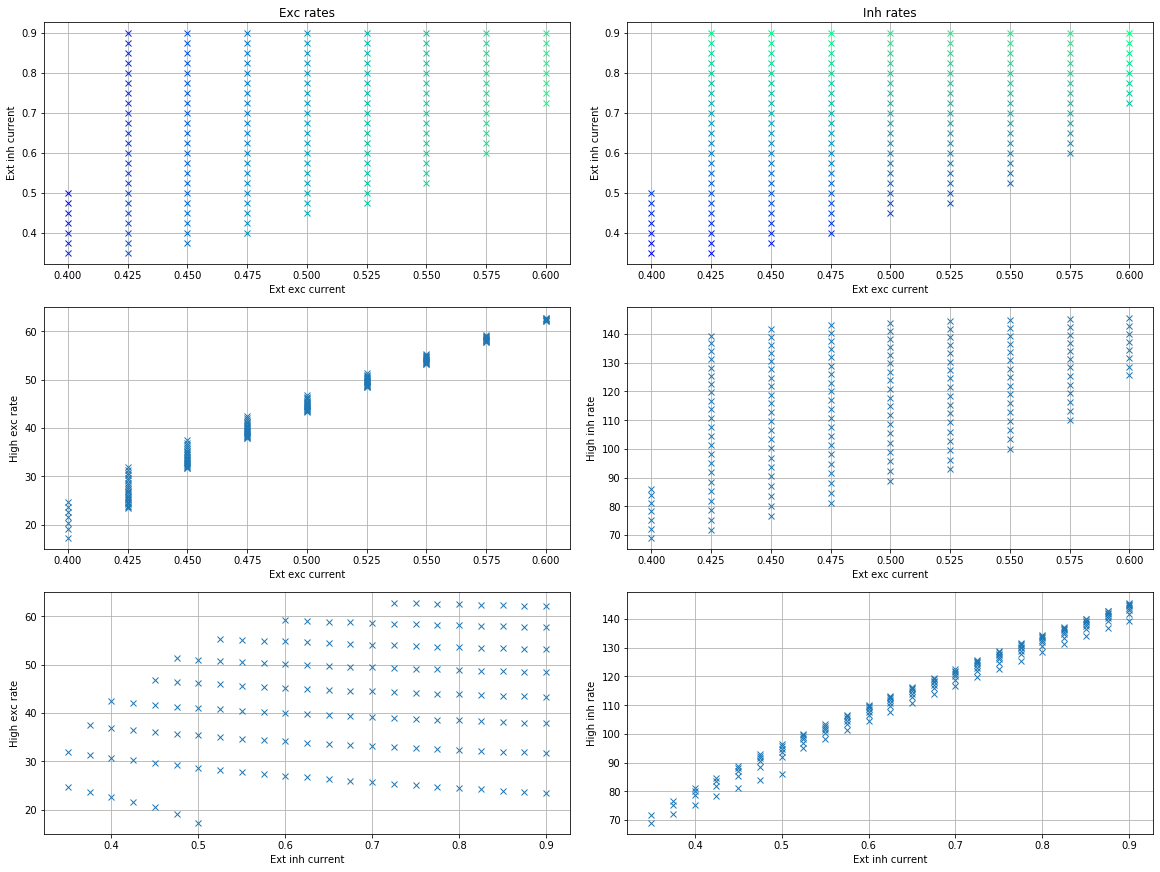

In [70]:
cmap = colormaps.get_cmap('winter')

fig0, ax = plt.subplots(3, 2, constrained_layout=True, figsize = (16,12) )

for i in range(len(ext_exc)):
    ax[0,0].plot(ext_exc[i], ext_inh[i], 'x', color = cmap(up_rates_norm[i,0]), label='normalized high rates')
    ax[0,1].plot(ext_exc[i], ext_inh[i], 'x', color = cmap(up_rates_norm[i,1]), label='normalized high rates')
    
#ax[0,0,].legend()
#ax[0,1].legend()
 
ax[0,0].set_xlabel('Ext exc current')
ax[0,1].set_xlabel('Ext exc current')
ax[0,0].set_ylabel('Ext inh current')
ax[0,1].set_ylabel('Ext inh current')

ax[1,0].plot(ext_exc, up_rates[:,0], 'x')
ax[1,1].plot(ext_exc, up_rates[:,1], 'x')
ax[1,0].set_xlabel('Ext exc current')
ax[1,1].set_xlabel('Ext exc current')
ax[1,0].set_ylabel('High exc rate')
ax[1,1].set_ylabel('High inh rate')
ax[2,0].plot(ext_inh, up_rates[:,0], 'x')
ax[2,1].plot(ext_inh, up_rates[:,1], 'x')
ax[2,0].set_xlabel('Ext inh current')
ax[2,1].set_xlabel('Ext inh current')
ax[2,0].set_ylabel('High exc rate')
ax[2,1].set_ylabel('High inh rate')

cols = ['Exc rates', 'Inh rates']
pad = 5 # in points

for ax_, col in zip(ax[0], cols):
    ax_.annotate(col, xy=(0.5, 1), xytext=(0, pad),
                xycoords='axes fraction', textcoords='offset points',
                size='large', ha='center', va='baseline')

plt.show()

- excitatory high rates are mainly determined by the external excitatory current
- inhibitory high rates are mainly determined by the external inhibitory current

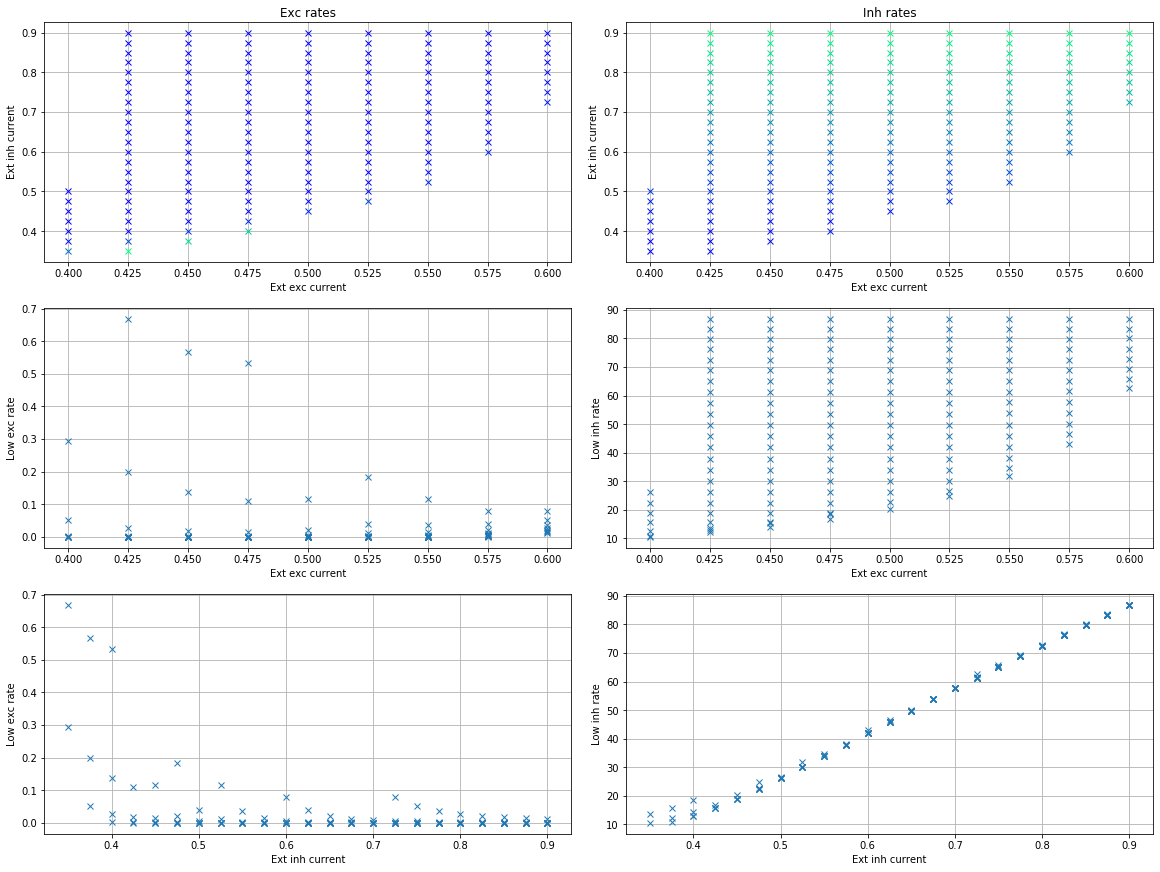

In [71]:
fig1, ax = plt.subplots(3, 2, constrained_layout=True, figsize = (16,12) )

for i in range(len(ext_exc)):
    ax[0,0].plot(ext_exc[i], ext_inh[i], 'x', color = cmap(down_rates_norm[i,0]))
    ax[0,1].plot(ext_exc[i], ext_inh[i], 'x', color = cmap(down_rates_norm[i,1]))
 
ax[0,0].set_xlabel('Ext exc current')
ax[0,1].set_xlabel('Ext exc current')
ax[0,0].set_ylabel('Ext inh current')
ax[0,1].set_ylabel('Ext inh current')

ax[1,0].plot(ext_exc, down_rates[:,0], 'x')
ax[1,1].plot(ext_exc, down_rates[:,1], 'x')
ax[1,0].set_xlabel('Ext exc current')
ax[1,1].set_xlabel('Ext exc current')
ax[1,0].set_ylabel('Low exc rate')
ax[1,1].set_ylabel('Low inh rate')
ax[2,0].plot(ext_inh, down_rates[:,0], 'x')
ax[2,1].plot(ext_inh, down_rates[:,1], 'x')
ax[2,0].set_xlabel('Ext inh current')
ax[2,1].set_xlabel('Ext inh current')
ax[2,0].set_ylabel('Low exc rate')
ax[2,1].set_ylabel('Low inh rate')

cols = ['Exc rates', 'Inh rates']
pad = 5 # in points

for ax_, col in zip(ax[0], cols):
    ax_.annotate(col, xy=(0.5, 1), xytext=(0, pad),
                xycoords='axes fraction', textcoords='offset points',
                size='large', ha='center', va='baseline')

plt.show()

- excitatory low rates are close to zero in all cases
- inhibitory low rates are mainly determined by depend on external inhibitory current
- distance between high and low inhibitory rates slightly decreases with higher external inhibitory currents

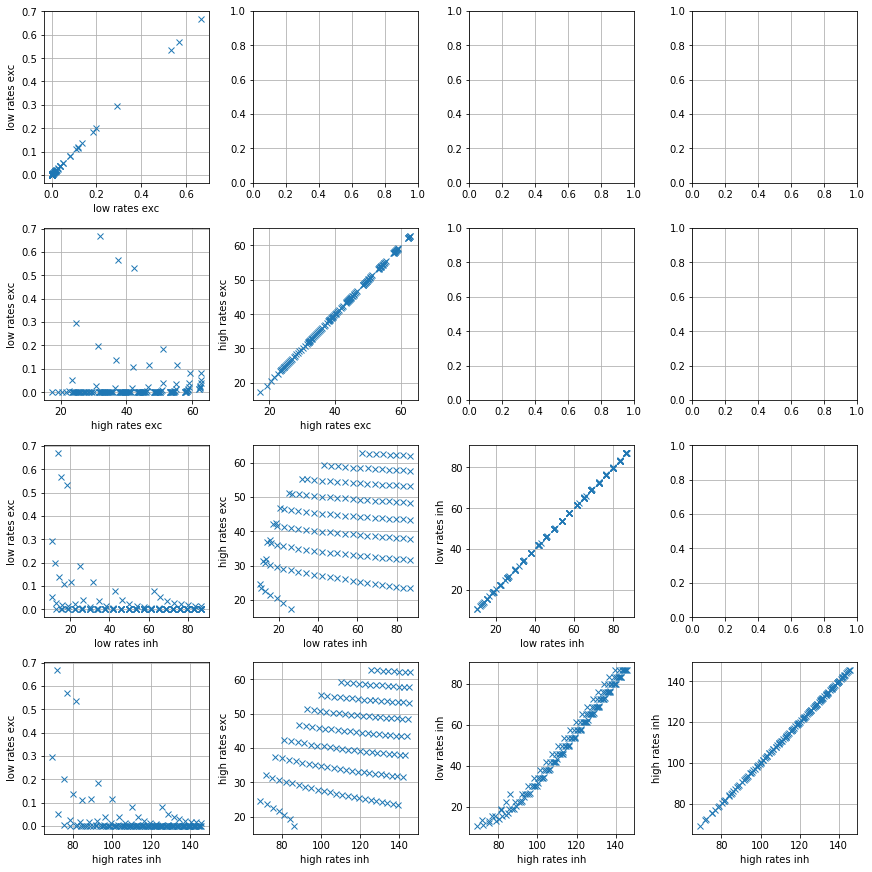

In [9]:
fig2, ax = plt.subplots(4, 4, constrained_layout=True, figsize = (12,12) )
ax[0,0].plot(down_rates[:,0], down_rates[:,0], 'x')
ax[0,0].set_xlabel('low rates exc')
ax[0,0].set_ylabel('low rates exc')

ax[1,0].plot(up_rates[:,0], down_rates[:,0], 'x')
ax[1,0].set_xlabel('high rates exc')
ax[1,0].set_ylabel('low rates exc')

ax[1,1].plot(up_rates[:,0], up_rates[:,0], 'x')
ax[1,1].set_xlabel('high rates exc')
ax[1,1].set_ylabel('high rates exc')

ax[2,0].plot(down_rates[:,1], down_rates[:,0], 'x')
ax[2,0].set_xlabel('low rates inh')
ax[2,0].set_ylabel('low rates exc')

ax[2,1].plot(down_rates[:,1], up_rates[:,0], 'x')
ax[2,1].set_xlabel('low rates inh')
ax[2,1].set_ylabel('high rates exc')

ax[2,2].plot(down_rates[:,1], down_rates[:,1], 'x')
ax[2,2].set_xlabel('low rates inh')
ax[2,2].set_ylabel('low rates inh')

ax[3,0].plot(up_rates[:,1], down_rates[:,0], 'x')
ax[3,0].set_xlabel('high rates inh')
ax[3,0].set_ylabel('low rates exc')

ax[3,1].plot(up_rates[:,1], up_rates[:,0], 'x')
ax[3,1].set_xlabel('high rates inh')
ax[3,1].set_ylabel('high rates exc')

ax[3,2].plot(up_rates[:,1], down_rates[:,1], 'x')
ax[3,2].set_xlabel('high rates inh')
ax[3,2].set_ylabel('low rates inh')

ax[3,3].plot(up_rates[:,1], up_rates[:,1], 'x')
ax[3,3].set_xlabel('high rates inh')
ax[3,3].set_ylabel('high rates inh')

plt.show()

- high and low inhibitory rates are strongly correlated

### Differences between up and down states in rates

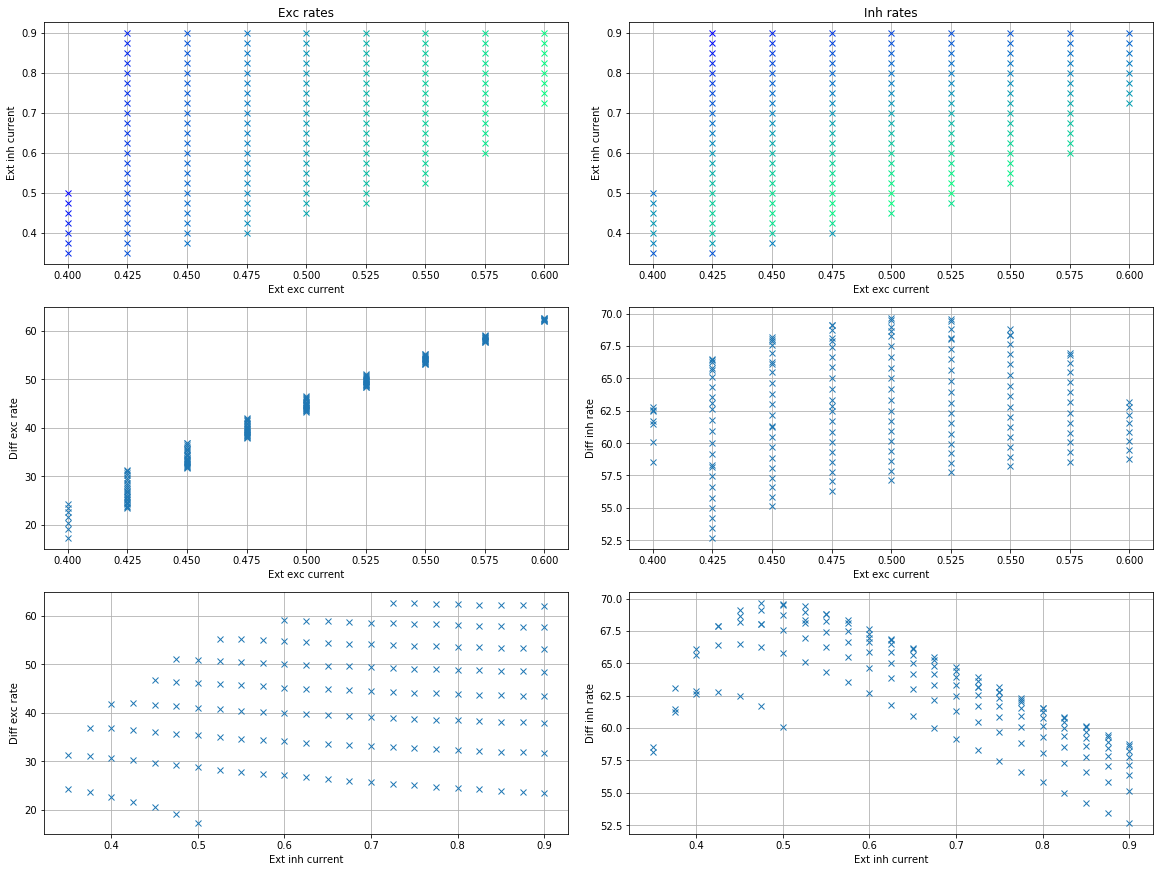

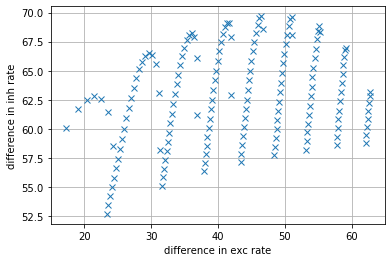

In [10]:
cmap = colormaps.get_cmap('winter')
fig2, ax = plt.subplots(3, 2, constrained_layout=True, figsize = (16,12) )

for i in range(len(ext_exc)):
    ax[0,0].plot(ext_exc[i], ext_inh[i], 'x', color = cmap(diff_rates_norm[i,0]))
    ax[0,1].plot(ext_exc[i], ext_inh[i], 'x', color = cmap(diff_rates_norm[i,1]))
 
ax[0,0].set_xlabel('Ext exc current')
ax[0,1].set_xlabel('Ext exc current')
ax[0,0].set_ylabel('Ext inh current')
ax[0,1].set_ylabel('Ext inh current')

ax[1,0].plot(ext_exc, diff_rates[:,0], 'x')
ax[1,1].plot(ext_exc, diff_rates[:,1], 'x')
ax[1,0].set_xlabel('Ext exc current')
ax[1,1].set_xlabel('Ext exc current')
ax[1,0].set_ylabel('Diff exc rate')
ax[1,1].set_ylabel('Diff inh rate')
ax[2,0].plot(ext_inh, diff_rates[:,0], 'x')
ax[2,1].plot(ext_inh, diff_rates[:,1], 'x')
ax[2,0].set_xlabel('Ext inh current')
ax[2,1].set_xlabel('Ext inh current')
ax[2,0].set_ylabel('Diff exc rate')
ax[2,1].set_ylabel('Diff inh rate')

cols = ['Exc rates', 'Inh rates']
pad = 5 # in points

for ax_, col in zip(ax[0], cols):
    ax_.annotate(col, xy=(0.5, 1), xytext=(0, pad),
                xycoords='axes fraction', textcoords='offset points',
                size='large', ha='center', va='baseline')

plt.show()

plt.plot(diff_rates[:,0], diff_rates[:,1], 'x')
plt.xlabel('difference in exc rate')
plt.ylabel('difference in inh rate')
plt.show()

- external excitatory current determines the difference in the excitatory rate between up and down state
- external inhibitory current determines the difference in the inhibitory rate between up and down state except for the low region close to the oscillatory regime

### Dependence of difference in rates on distance to regime boundary

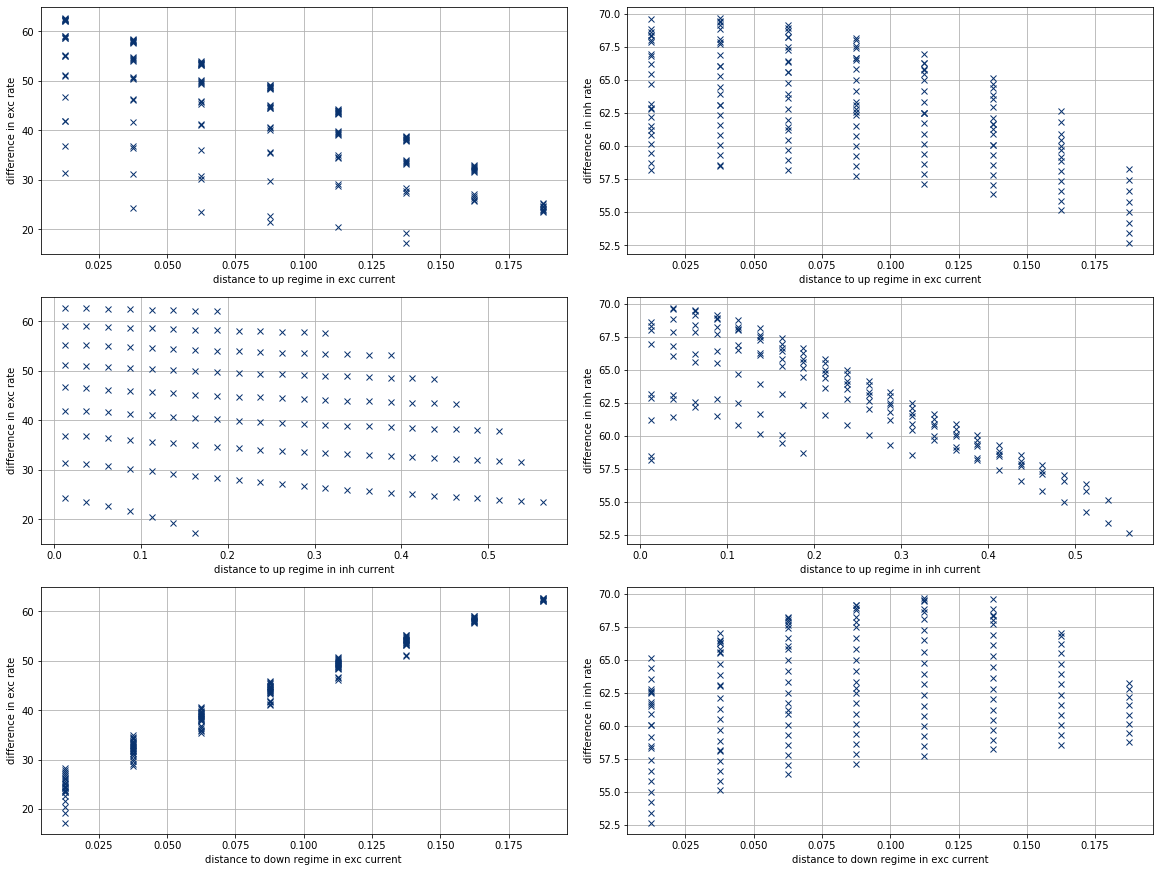

In [11]:
cmap = colormaps.get_cmap('Blues')
fig3, ax = plt.subplots(3, 2, constrained_layout=True, figsize = (16,12) )

for i in range(len(ext_exc)):
    ax[0,0].plot(dist_up_regime[i,0], diff_rates[i,0], 'x', color=cmap(0.99))
    ax[0,1].plot(dist_up_regime[i,0], diff_rates[i,1], 'x', color=cmap(0.99))
    ax[1,0].plot(dist_up_regime[i,1], diff_rates[i,0], 'x', color=cmap(0.99))
    ax[1,1].plot(dist_up_regime[i,1], diff_rates[i,1], 'x', color=cmap(0.99))
    ax[2,0].plot(dist_down_regime[i], diff_rates[i,0], 'x', color=cmap(0.99))
    ax[2,1].plot(dist_down_regime[i], diff_rates[i,1], 'x', color=cmap(0.99))
        
ax[0,0].set_xlabel('distance to up regime in exc current')
ax[0,0].set_ylabel('difference in exc rate')
ax[0,1].set_xlabel('distance to up regime in exc current')
ax[0,1].set_ylabel('difference in inh rate')
ax[1,0].set_xlabel('distance to up regime in inh current')
ax[1,0].set_ylabel('difference in exc rate')
ax[1,1].set_xlabel('distance to up regime in inh current')
ax[1,1].set_ylabel('difference in inh rate')
ax[2,0].set_xlabel('distance to down regime in exc current')
ax[2,0].set_ylabel('difference in exc rate')
ax[2,1].set_xlabel('distance to down regime in exc current')
ax[2,1].set_ylabel('difference in inh rate')

plt.show()

- high horizontal distance only works for low external excitatory current
- high vertical distance only works for high external inhibitory currents, where gap between high and low state decreases

In [40]:
def readcase(case_):
    
    global exc_, inh_, no_c_, both_c_
    global exc_1, inh_1, lenx_1, leny_1, exc_2, inh_2, lenx_2, leny_2
    global exc_3, inh_3, lenx_3, leny_3, exc_4, inh_4, lenx_4, leny_4, cost1, cost2, cost3, cost4
    global d_x, d_y, diff_x1, diff_y1, diff_x2, diff_y2, cost_p_x, cost_p_y, cost_s_x, cost_e_x, cost_s_y, cost_e_y
    global d_xy_sum, d_xy, dx3, dy3, cost_xy, cost_xy_sum, costx3, costy3, len3_sum, len3sqrt
    global d_attr_1, d_attr_2
    
    readpath = '.' + os.sep + 'data' + os.sep + str(case_[:5]) + os.sep

    data_array = data.read_data(readpath, case_)
    exc_, inh_, both_c_, no_c_ = data_array[0:4]
    exc_1, inh_1, lenx_1, leny_1, exc_2, inh_2, lenx_2, leny_2 = data_array[4:12]
    exc_3, inh_3, lenx_3, leny_3, exc_4, inh_4, lenx_4, leny_4, cost1, cost2, cost3, cost4 = data_array[12:]

    control_data = data.read_control(readpath, case_)
    opt_control = control_data[2]
    opt_cost = control_data[3]
    
    d_x = []
    d_y = []
    d_xy_sum = []
    d_xy = []
    dx3 = []
    dy3 = []
    len3_sum = []
    len3sqrt = []
    
    if case_[0] == '0':
        for i in range(len(exc_1)):
            d_x.append(data.dist_right(exc_1[i], inh_1[i], ext_exc, ext_inh, grid_resolution))
        for i in range(len(exc_2)):
            d_y.append(data.dist_low(exc_2[i], inh_2[i], ext_exc, ext_inh, grid_resolution))
        for i in range(len(exc_3)):
            dx3.append(data.dist_right(exc_3[i], inh_3[i], ext_exc, ext_inh, grid_resolution))
            dy3.append(data.dist_low(exc_3[i], inh_3[i], ext_exc, ext_inh, grid_resolution))
            d_xy_sum.append(dx3[-1] + dy3[-1])
            len3_sum.append( np.abs(lenx_3[i]) + np.abs(leny_3[i]) )
            d_xy.append( np.sqrt( dx3[-1]**2 + dy3[-1]**2 ) )
            len3sqrt.append( np.sqrt( lenx_3[i]**2 + leny_3[i]**2  ))
    else:
        for i in range(len(exc_1)):
            d_x.append(data.dist_left(exc_1[i], inh_1[i], ext_exc, ext_inh, grid_resolution))
        for i in range(len(exc_2)):
            d_y.append(data.dist_up(exc_2[i], inh_2[i], ext_exc, ext_inh, grid_resolution))
        for i in range(len(exc_3)):
            dx3.append(data.dist_left(exc_3[i], inh_3[i], ext_exc, ext_inh, grid_resolution))
            dy3.append(data.dist_up(exc_3[i], inh_3[i], ext_exc, ext_inh, grid_resolution))
            d_xy_sum.append(dx3[-1] + dy3[-1])
            len3_sum.append( np.abs(lenx_3[i]) + np.abs(leny_3[i]) )
            d_xy.append( np.sqrt( dx3[-1]**2 + dy3[-1]**2 ) )
            len3sqrt.append( np.sqrt( lenx_3[i]**2 + leny_3[i]**2  ))
            
    diff_x1 = []
    diff_x2 = []
    diff_y1 = []
    diff_y2 = []
    
    for i in range(len(exc_1)):
        diff_x1.append(diff_rates[i,0])
        diff_y1.append(diff_rates[i,1])
    for i in range(len(exc_2)):
        diff_x2.append(diff_rates[i,0])
        diff_y2.append(diff_rates[i,1])
        
    cost_p_x = []
    cost_p_y = []
    cost_s_x = []
    cost_e_x = []
    cost_s_y = []
    cost_e_y = []
    
    cost_xy = []
    costx3 = []
    costy3 = []
    cost_xy_sum = []
    

    for i in range(len(d_x)):
        cost_p_x.append(cost1[i][0][0][0])
        cost_s_x.append(cost1[i][2][0][0])
        cost_e_x.append(cost1[i][1][0][0])
    for i in range(len(d_y)):
        cost_p_y.append(cost2[i][0][0][1])
        cost_s_y.append(cost2[i][2][0][1])
        cost_e_y.append(cost2[i][1][0][1])
    for i in range(len(dx3)):
        costx3.append(cost3[i][1][0][0])
        costy3.append(cost3[i][1][0][1])
        cost_xy_sum.append( costx3[-1] + costy3[-1] )
        cost_xy.append( np.sqrt( costx3[-1]**2 + costy3[-1]**2 ) )
                
    d_attr_1 = []
    d_attr_2 = []
    for i in range(len(ext_exc)):
        for j in range(len(exc_1)):
            if exc_1[j] == ext_exc[i] and inh_1[j] == ext_inh[i]:
                d_attr_1.append(dist_attractor_rate_perc[i])
                
    for i in range(len(ext_exc)):
        for j in range(len(exc_2)):
            if exc_2[j] == ext_exc[i] and inh_2[j] == ext_inh[i]:
                #print(i, j, exc_2[j], ext_exc[i], inh_2[j], ext_inh[i])
                d_attr_2.append(dist_attractor_rate_perc[i])

### min, max, average cost per case

In [103]:
# low => high
opt_cond = ['0', '1']
balance = ['0', '1']
init = ['0', '1', '2', '3', '4', '5']
duration = ['0', '1']

string_table = 'Task & Optimality condition & Duration & Initial node & Min cost (e, i, 2) &'
string_table = string_table + ' Max cost (e, i, 2) & Mean cost (e, i, 2) \\' + '\\ \n'


for o in opt_cond:
    for b in balance:
        for d in duration:
            
            string_table = string_table + '\\hline \n'
            
            for ini in init:
                
                if d == '0' and ini in ['3', '4', '5']:
                    continue
                    
                if b == '0' and o == '1' and ini in ['3', '4', '5']:
                    continue
                
                string_table = string_table + 'low $\\rightarrow$ high & '
                
                if b == '0' and o == '0':
                    string_table = string_table + 'sparsity balanced & '
                elif b == '0' and o == '1':
                    string_table = string_table + 'energy balanced & '
                elif b == '1' and o == '0':
                    string_table = string_table + 'sparsity minimal & '
                elif b == '1' and o == '1':
                    string_table = string_table + 'energy minimal & '
                    
                if d == '0':
                    string_table = string_table + '100 ms & '
                elif d == '1':
                    string_table = string_table + '400 ms & '
                
                if ini == '0':
                    string_table = string_table + 'excitatory & '
                elif ini == '1':
                    string_table = string_table + 'inhibitory & '
                elif ini == '2':
                    string_table = string_table + '2 node & '
                elif ini == '3':
                    string_table = string_table + '100ms exc & '
                elif ini == '4':
                    string_table = string_table + '100ms inh & '
                elif ini == '5':
                    string_table = string_table + '100ms 2 node & '
                
                case = '0' + o + b + ini + d
                readcase(case)
                
                if o == '0':
                    ind_cost = 2
                elif o == '1':
                    ind_cost = 1
                
                total_cost1 = []
                for i in range(len(cost1)):
                    total_cost1.append( sum(cost1[i][0][0][:]) + sum(cost1[i][ind_cost][0][:]) )
                    
                total_cost2 = []
                for i in range(len(cost2)):
                    total_cost2.append( sum(cost2[i][0][0][:]) + sum(cost2[i][ind_cost][0][:]) ) 
                    
                total_cost3 = []
                for i in range(len(cost3)):
                    total_cost3.append( sum(cost3[i][0][0][:]) + sum(cost3[i][ind_cost][0][:]) )
                    
                if len(total_cost1) == 0:
                    total_cost1.append(0.)
                if len(total_cost2) == 0:
                    total_cost2.append(0.)
                if len(total_cost3) == 0:
                    total_cost3.append(0.)
                    
                print('case = ', case, ', min cost = ',  np.round(np.amin(total_cost1),2), ' (e), ',
                                                         np.round(np.amin(total_cost2),2), ' (i), ',
                                                         np.round(np.amin(total_cost3),2), ' (2)')
                
                string_table = ( string_table + str(np.round(np.amin(total_cost1),2)) + ', ' + 
                                                str(np.round(np.amin(total_cost2),2)) + ', ' + 
                                                str(np.round(np.amin(total_cost3),2)) + ' & ')
                
                print('                max cost = ',  np.round(np.amax(total_cost1),2), ' (e), ',
                                                      np.round(np.amax(total_cost2),2), ' (i), ',
                                                      np.round(np.amax(total_cost3),2), ' (2)')
                
                string_table = ( string_table + str(np.round(np.amax(total_cost1),2)) + ', ' + 
                                                str(np.round(np.amax(total_cost2),2)) + ', ' + 
                                                str(np.round(np.amax(total_cost3),2)) + ' & ')
                
                print('                mean cost = ',  np.round(np.mean(total_cost1),2), ' (e), ',
                                                       np.round(np.mean(total_cost2),2), ' (i), ',
                                                       np.round(np.mean(total_cost3),2), ' (2)')
                                
                string_table = ( string_table + str(np.round(np.mean(total_cost1),2)) + ', ' + 
                                                str(np.round(np.mean(total_cost2),2)) + ', ' + 
                                                str(np.round(np.mean(total_cost3),2)) + ' \\' + '\\ \n')
                                
                                

print(string_table)

case =  00000 , min cost =  0.64  (e),  0.0  (i),  1.17  (2)
                max cost =  8.76  (e),  0.0  (i),  3.33  (2)
                mean cost =  4.47  (e),  0.0  (i),  2.35  (2)
case =  00010 , min cost =  0.0  (e),  1.11  (i),  0.79  (2)
                max cost =  0.0  (e),  38.16  (i),  19.25  (2)
                mean cost =  0.0  (e),  9.33  (i),  8.39  (2)
case =  00020 , min cost =  0.64  (e),  0.0  (i),  1.11  (2)
                max cost =  8.58  (e),  0.0  (i),  9.61  (2)
                mean cost =  4.12  (e),  0.0  (i),  5.12  (2)
case =  00001 , min cost =  0.32  (e),  0.0  (i),  1.04  (2)
                max cost =  3.85  (e),  0.0  (i),  2.53  (2)
                mean cost =  2.3  (e),  0.0  (i),  2.01  (2)
case =  00011 , min cost =  0.0  (e),  0.99  (i),  0.33  (2)
                max cost =  0.0  (e),  7.28  (i),  12.2  (2)
                mean cost =  0.0  (e),  4.3  (i),  5.77  (2)
case =  00021 , min cost =  0.32  (e),  0.0  (i),  0.99  (2)
                max

### maximum amplitude as a function of distance to regime boundary, sparsity enforced

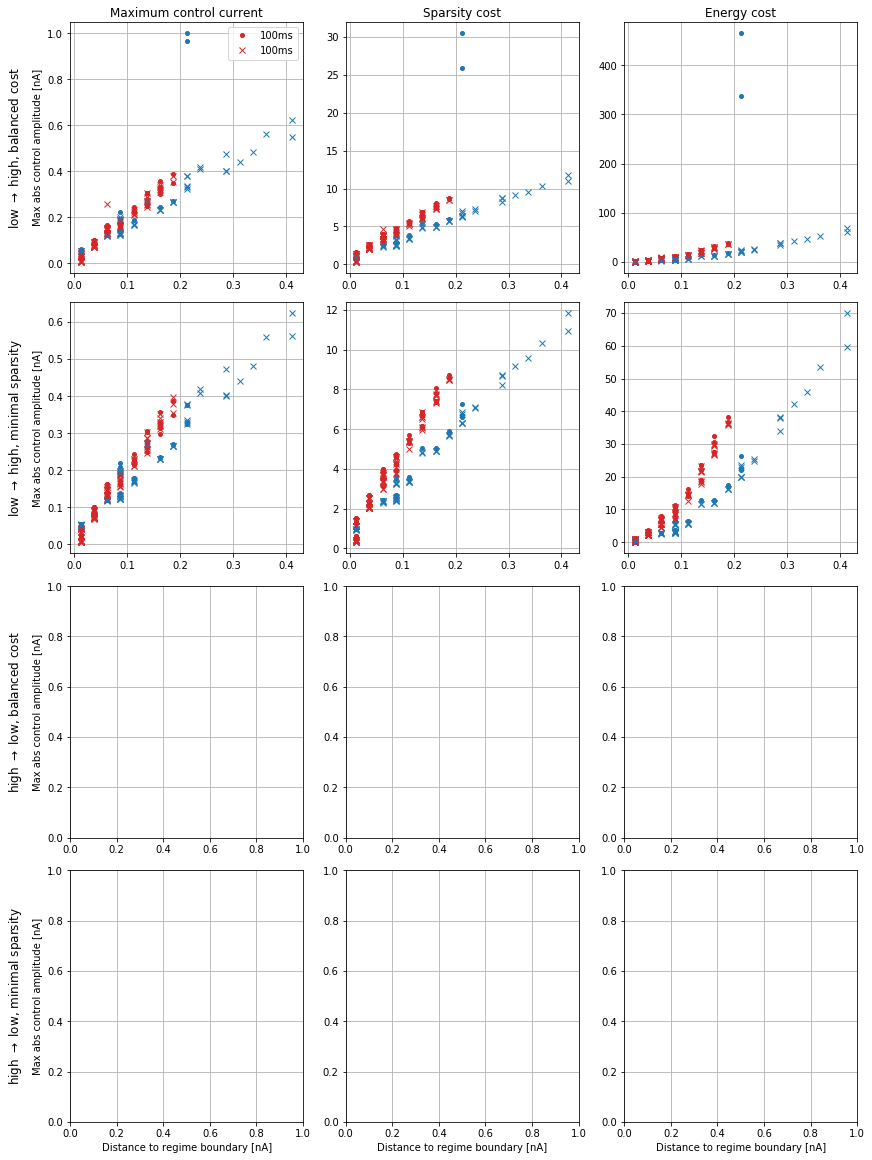

In [104]:
fig5, ax = plt.subplots(4, 3, constrained_layout=True, figsize = (12,16) )

#########################################
for c in ['00000', '00010', '00020']:
    readcase(c)
    ax[0,0].plot(d_x, lenx_1, 'o', color=exc_red, markersize=4)
    ax[0,0].plot(d_y, np.abs(leny_2), 'o', color=inh_blue, markersize=4)
    ax[0,1].plot(d_x, cost_s_x, 'o', color=exc_red, markersize=4)
    ax[0,1].plot(d_y, cost_s_y, 'o', color=inh_blue, markersize=4)
    ax[0,2].plot(d_x, cost_e_x, 'o', color=exc_red, markersize=4)
    ax[0,2].plot(d_y, cost_e_y, 'o', color=inh_blue, markersize=4)
    
for c in ['00001', '00011', '00021', '00031', '00041', '00051']:
    readcase(c)
    ax[0,0].plot(d_x, lenx_1, 'x', color=exc_red, markersize=6)
    ax[0,0].plot(d_y, np.abs(leny_2), 'x', color=inh_blue, markersize=6)
    ax[0,1].plot(d_x, cost_s_x, 'x', color=exc_red, markersize=6)
    ax[0,1].plot(d_y, cost_s_y, 'x', color=inh_blue, markersize=6)
    ax[0,2].plot(d_x, cost_e_x, 'x', color=exc_red, markersize=6)
    ax[0,2].plot(d_y, cost_e_y, 'x', color=inh_blue, markersize=6)


#########################################
for c in ['00100', '00110', '00120']:
    readcase(c)
    ax[1,0].plot(d_x, lenx_1, 'o', color=exc_red, markersize=4)
    ax[1,0].plot(d_y, np.abs(leny_2), 'o', color=inh_blue, markersize=4)
    ax[1,1].plot(d_x, cost_s_x, 'o', color=exc_red, markersize=4)
    ax[1,1].plot(d_y, cost_s_y, 'o', color=inh_blue, markersize=4)
    ax[1,2].plot(d_x, cost_e_x, 'o', color=exc_red, markersize=4)
    ax[1,2].plot(d_y, cost_e_y, 'o', color=inh_blue, markersize=4)

for c in ['00101', '00111', '00121', '00131', '00141', '00151']:
    readcase(c)
    ax[1,0].plot(d_x, lenx_1, 'x', color=exc_red, markersize=6)
    ax[1,0].plot(d_y, np.abs(leny_2), 'x', color=inh_blue, markersize=6)
    ax[1,1].plot(d_x, cost_s_x, 'x', color=exc_red, markersize=6)
    ax[1,1].plot(d_y, cost_s_y, 'x', color=inh_blue, markersize=6)
    ax[1,2].plot(d_x, cost_e_x, 'x', color=exc_red, markersize=6)
    ax[1,2].plot(d_y, cost_e_y, 'x', color=inh_blue, markersize=6)

"""
#########################################
for c in ['10000', '10010', '10020']:
    readcase(c)
    ax[2,0].plot(d_x, lenx_1, 'o', color=exc_red, markersize=4)
    ax[2,0].plot(d_y, np.abs(leny_2), 'o', color=inh_blue, markersize=4)
    ax[2,1].plot(d_x, cost_s_x, 'o', color=exc_red, markersize=4)
    ax[2,1].plot(d_y, cost_s_y, 'o', color=inh_blue, markersize=4)
    ax[2,2].plot(d_x, cost_e_x, 'o', color=exc_red, markersize=4)
    ax[2,2].plot(d_y, cost_e_y, 'o', color=inh_blue, markersize=4)
    
for c in ['10001', '10011', '10021']:
    readcase(c)
    ax[2,0].plot(d_x, lenx_1, 'x', color=exc_red, markersize=6)
    ax[2,0].plot(d_y, np.abs(leny_2), 'x', color=inh_blue, markersize=6)
    ax[2,1].plot(d_x, cost_s_x, 'x', color=exc_red, markersize=6)
    ax[2,1].plot(d_y, cost_s_y, 'x', color=inh_blue, markersize=6)
    ax[2,2].plot(d_x, cost_e_x, 'x', color=exc_red, markersize=6)
    ax[2,2].plot(d_y, cost_e_y, 'x', color=inh_blue, markersize=6)

#########################################
for c in ['10100', '10110', '10120']:
    readcase(c)
    ax[3,0].plot(d_x, lenx_1, 'o', color=exc_red, markersize=4)
    ax[3,0].plot(d_y, np.abs(leny_2), 'o', color=inh_blue, markersize=4)
    ax[3,1].plot(d_x, cost_s_x, 'o', color=exc_red, markersize=4)
    ax[3,1].plot(d_y, cost_s_y, 'o', color=inh_blue, markersize=4)
    ax[3,2].plot(d_x, cost_e_x, 'o', color=exc_red, markersize=4)
    ax[3,2].plot(d_y, cost_e_y, 'o', color=inh_blue, markersize=4)
    
for c in ['10101', '10111', '10121']:
    readcase(c)
    ax[3,0].plot(d_x, lenx_1, 'x', color=exc_red, markersize=6)
    ax[3,0].plot(d_y, np.abs(leny_2), 'x', color=inh_blue, markersize=6)
    ax[3,1].plot(d_x, cost_s_x, 'x', color=exc_red, markersize=6)
    ax[3,1].plot(d_y, cost_s_y, 'x', color=inh_blue, markersize=6)
    ax[3,2].plot(d_x, cost_e_x, 'x', color=exc_red, markersize=6)
    ax[3,2].plot(d_y, cost_e_y, 'x', color=inh_blue, markersize=6)
"""

ax[3,0].set_xlabel("Distance to regime boundary [nA]")
ax[3,1].set_xlabel("Distance to regime boundary [nA]")
ax[3,2].set_xlabel("Distance to regime boundary [nA]")
ax[0,0].set_ylabel("Max abs control amplitude [nA]")
ax[1,0].set_ylabel("Max abs control amplitude [nA]")
ax[2,0].set_ylabel("Max abs control amplitude [nA]")
ax[3,0].set_ylabel("Max abs control amplitude [nA]")

label_100 = mlines.Line2D([], [], color=exc_red, marker='o', linestyle='None',
                          markersize=4, label='100ms')
label_400 = mlines.Line2D([], [], color=exc_red, marker='x', linestyle='None',
                          markersize=6, label='100ms')

ax[0,0].legend(handles=[label_100, label_400])

cols = ['Maximum control current', 'Sparsity cost', 'Energy cost']
rows = [r'low $\rightarrow$ high, balanced cost', r'low $\rightarrow$ high, minimal sparsity',
        r'high $\rightarrow$ low, balanced cost', r'high $\rightarrow$ low, minimal sparsity']

pad = 5 # in points

for ax_, col in zip(ax[0], cols):
    ax_.annotate(col, xy=(0.5, 1), xytext=(0, pad),
                xycoords='axes fraction', textcoords='offset points',
                size='large', ha='center', va='baseline')

for ax_, row in zip(ax[:,0], rows):
    ax_.annotate(row, xy=(0, 0.5), xytext=(-ax_.yaxis.labelpad - pad, 0),
                xycoords=ax_.yaxis.label, textcoords='offset points',
                size='large', ha='right', va='center', rotation=90)

plt.savefig( os.path.join(os.getcwd(), 'ampl_dist.png') )
plt.show()

### maximum amplitude (geometric sum) as a function of distance to regime boundary (geometric sum), energy enforced

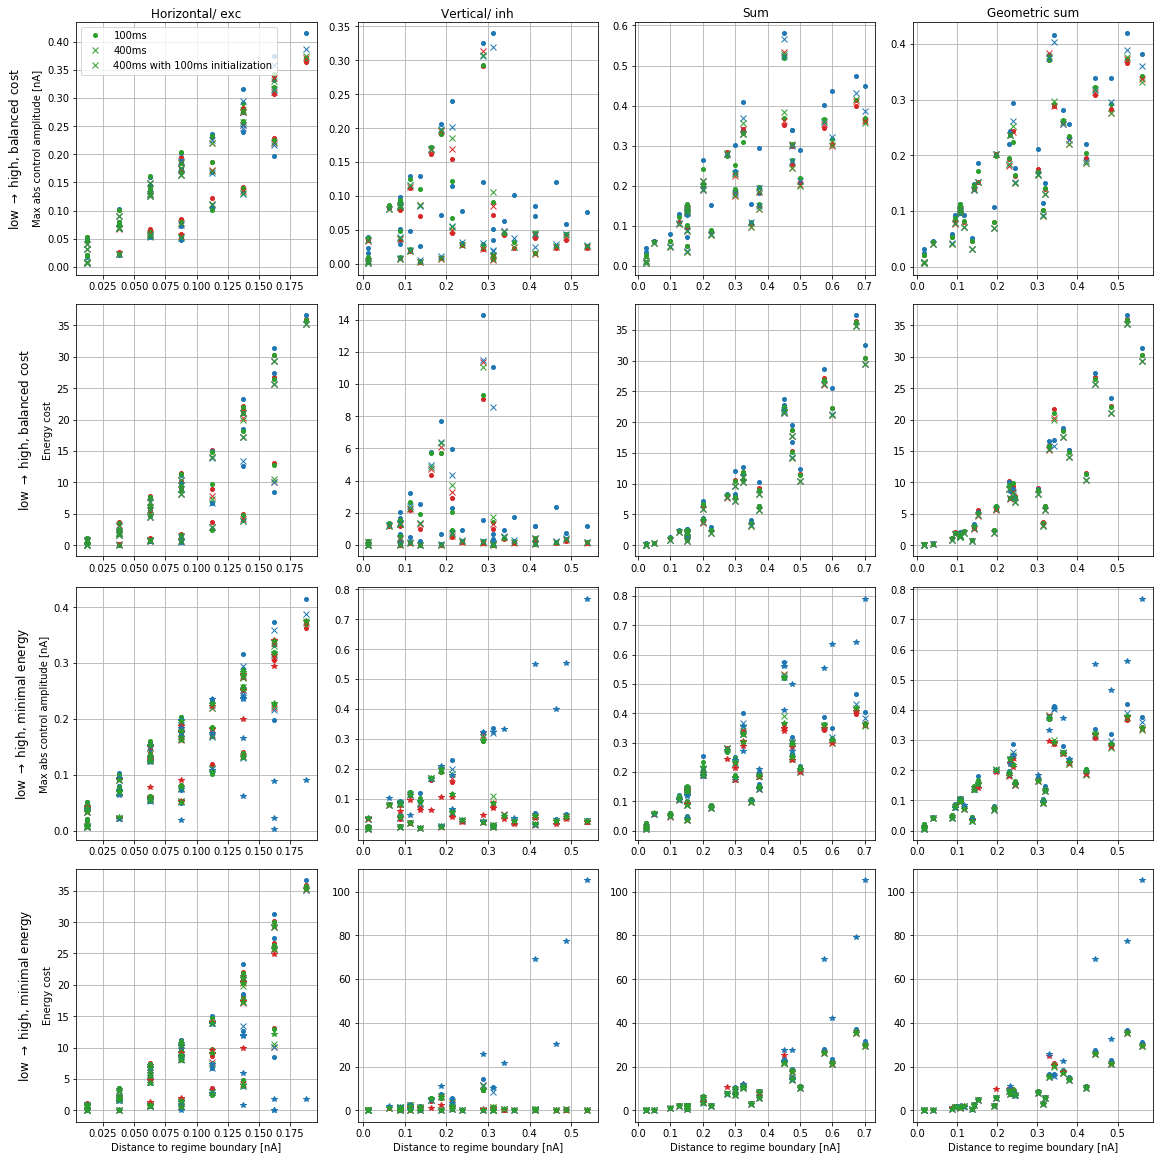

In [105]:
fig5b, ax = plt.subplots(4, 4, constrained_layout=True, figsize = (16,16) )

color_array = [exc_red, inh_blue, green, exc_red, inh_blue, green]
range_1 = ['01000', '01010', '01020']
range_2 = ['01001', '01011', '01021']#, '01031', '01041', '01051']
range_3 = ['01100', '01110', '01120']
range_4 = ['01101', '01111', '01121']
range_5 = ['01131', '01141', '01151']

#########################################
for c in range(len(range_1)):
    readcase(range_1[c])
    ax[0,0].plot(dx3, lenx_3, 'o', color=color_array[c], markersize=4)
    ax[0,1].plot(dy3, np.abs(leny_3), 'o', color=color_array[c], markersize=4)
    ax[0,2].plot(d_xy_sum, len3_sum, 'o', color=color_array[c], markersize=4)
    ax[0,3].plot(d_xy, len3sqrt, 'o', color=color_array[c], markersize=4)
    
    ax[1,0].plot(dx3, costx3, 'o', color=color_array[c], markersize=4)
    ax[1,1].plot(dy3, costy3, 'o', color=color_array[c], markersize=4)
    ax[1,2].plot(d_xy_sum, cost_xy_sum, 'o', color=color_array[c], markersize=4)
    ax[1,3].plot(d_xy, cost_xy, 'o', color=color_array[c], markersize=4)

for c in range(len(range_2)):
    readcase(range_2[c])
    ax[0,0].plot(dx3, lenx_3, 'x', color=color_array[c], markersize=6)
    ax[0,1].plot(dy3, np.abs(leny_3), 'x', color=color_array[c], markersize=6)
    ax[0,2].plot(d_xy_sum, len3_sum, 'x', color=color_array[c], markersize=6)
    ax[0,3].plot(d_xy, len3sqrt, 'x', color=color_array[c], markersize=6)
    
    ax[1,0].plot(dx3, costx3, 'x', color=color_array[c], markersize=6)
    ax[1,1].plot(dy3, costy3, 'x', color=color_array[c], markersize=6)
    ax[1,2].plot(d_xy_sum, cost_xy_sum, 'x', color=color_array[c], markersize=6)
    ax[1,3].plot(d_xy, cost_xy, 'x', color=color_array[c], markersize=6)

#########################################
for c in range(len(range_3)):
    readcase(range_3[c])
    ax[2,0].plot(dx3, lenx_3, 'o', color=color_array[c], markersize=4)
    ax[2,1].plot(dy3, np.abs(leny_3), 'o', color=color_array[c], markersize=4)
    ax[2,2].plot(d_xy_sum, len3_sum, 'o', color=color_array[c], markersize=4)
    ax[2,3].plot(d_xy, len3sqrt, 'o', color=color_array[c], markersize=4)
    
    ax[3,0].plot(dx3, costx3, 'o', color=color_array[c], markersize=4)
    ax[3,1].plot(dy3, costy3, 'o', color=color_array[c], markersize=4)
    ax[3,2].plot(d_xy_sum, cost_xy_sum, 'o', color=color_array[c], markersize=4)
    ax[3,3].plot(d_xy, cost_xy, 'o', color=color_array[c], markersize=4)

for c in range(len(range_4)):
    readcase(range_4[c])
    ax[2,0].plot(dx3, lenx_3, 'x', color=color_array[c], markersize=6)
    ax[2,1].plot(dy3, np.abs(leny_3), 'x', color=color_array[c], markersize=6)
    ax[2,2].plot(d_xy_sum, len3_sum, 'x', color=color_array[c], markersize=6)
    ax[2,3].plot(d_xy, len3sqrt, 'x', color=color_array[c], markersize=6)
    
    ax[3,0].plot(dx3, costx3, 'x', color=color_array[c], markersize=6)
    ax[3,1].plot(dy3, costy3, 'x', color=color_array[c], markersize=6)
    ax[3,2].plot(d_xy_sum, cost_xy_sum, 'x', color=color_array[c], markersize=6)
    ax[3,3].plot(d_xy, cost_xy, 'x', color=color_array[c], markersize=6)
    
for c in range(len(range_5)):
    readcase(range_5[c])
    ax[2,0].plot(dx3, lenx_3, '*', color=color_array[c], markersize=6)
    ax[2,1].plot(dy3, np.abs(leny_3), '*', color=color_array[c], markersize=6)
    ax[2,2].plot(d_xy_sum, len3_sum, '*', color=color_array[c], markersize=6)
    ax[2,3].plot(d_xy, len3sqrt, '*', color=color_array[c], markersize=6)
    
    ax[3,0].plot(dx3, costx3, '*', color=color_array[c], markersize=6)
    ax[3,1].plot(dy3, costy3, '*', color=color_array[c], markersize=6)
    ax[3,2].plot(d_xy_sum, cost_xy_sum, '*', color=color_array[c], markersize=6)
    ax[3,3].plot(d_xy, cost_xy, '*', color=color_array[c], markersize=6)

ax[3,0].set_xlabel("Distance to regime boundary [nA]")
ax[3,1].set_xlabel("Distance to regime boundary [nA]")
ax[3,2].set_xlabel("Distance to regime boundary [nA]")
ax[3,3].set_xlabel("Distance to regime boundary [nA]")
ax[0,0].set_ylabel("Max abs control amplitude [nA]")
ax[1,0].set_ylabel("Energy cost")
ax[2,0].set_ylabel("Max abs control amplitude [nA]")
ax[3,0].set_ylabel("Energy cost")

label_100 = mlines.Line2D([], [], color=green, marker='o', linestyle='None', markersize=4, label='100ms')
label_400 = mlines.Line2D([], [], color=green, marker='x', linestyle='None', markersize=6, label='400ms')
label_400_init = mlines.Line2D([], [], color=green, marker='x', linestyle='None', markersize=6,
                               label='400ms with 100ms initialization')

ax[0,0].legend(handles=[label_100, label_400, label_400_init])

cols = ['Horizontal/ exc', 'Vertical/ inh', 'Sum', 'Geometric sum']
rows = [r'low $\rightarrow$ high, balanced cost', r'low $\rightarrow$ high, balanced cost',
        r'low $\rightarrow$ high, minimal energy', r'low $\rightarrow$ high, minimal energy']

pad = 5 # in points

for ax_, col in zip(ax[0], cols):
    ax_.annotate(col, xy=(0.5, 1), xytext=(0, pad),
                xycoords='axes fraction', textcoords='offset points',
                size='large', ha='center', va='baseline')

for ax_, row in zip(ax[:,0], rows):
    ax_.annotate(row, xy=(0, 0.5), xytext=(-ax_.yaxis.labelpad - pad, 0),
                xycoords=ax_.yaxis.label, textcoords='offset points',
                size='large', ha='right', va='center', rotation=90)

plt.savefig( os.path.join(os.getcwd(), 'ampl_dist_energy.png') )
plt.show()

### Two-node and one-node solutions in sparsity-restricted state switching

low $\rightarrow$ high, balanced cost, 100ms
case =  00000
case =  00010
case =  00020
low $\rightarrow$ high, balanced cost, 400ms
case =  00001
case =  00011
case =  00021
low $\rightarrow$ high, minimal sparsity, 100ms
case =  00100
large cost :  35 0.5500000000000003 0.5250000000000002 443.56052156105267
large cost :  75 0.5750000000000002 0.6750000000000004 219.2316495994528
large cost :  90 0.6000000000000003 0.7250000000000004 605.7190113889083
large cost :  105 0.5750000000000002 0.7750000000000005 238.68185641011948
large cost :  130 0.6000000000000003 0.8500000000000005 276.8223198611988
case =  00110
large cost :  10 0.4250000000000001 0.42500000000000016 254.6961651578819
large cost :  20 0.4500000000000001 0.4750000000000002 213.83478778900883
large cost :  35 0.5500000000000003 0.5250000000000002 441.974039625797
large cost :  40 0.5250000000000001 0.5500000000000003 295.46849142026815
large cost :  45 0.5000000000000002 0.5750000000000003 215.3649889971288
large cost :  

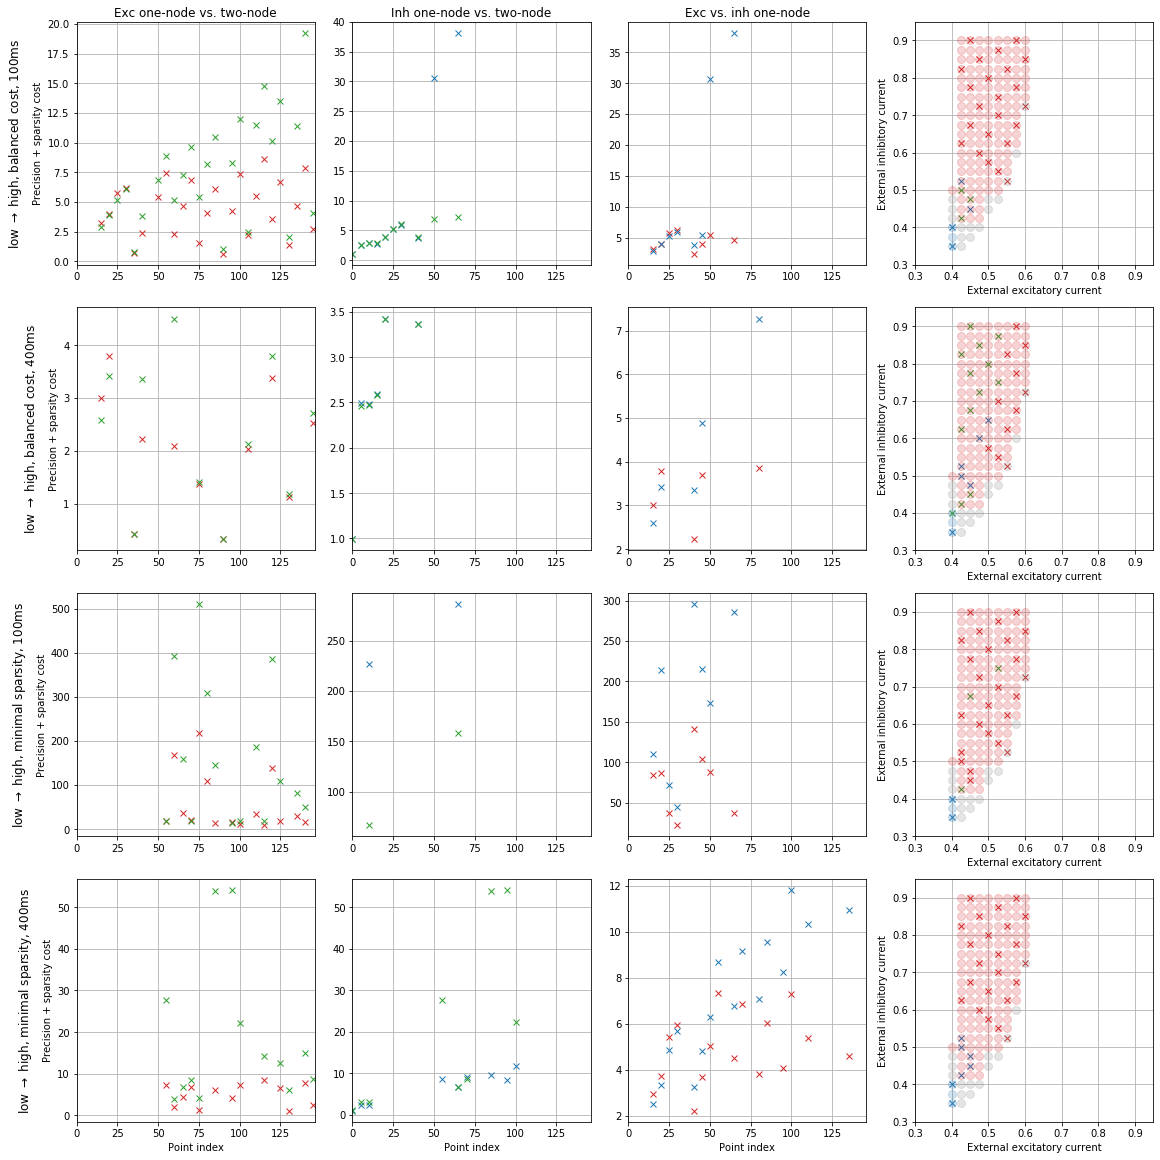

In [74]:
fig7, ax = plt.subplots(4, 4, constrained_layout=True, figsize = (16,16) )

rows = [r'low $\rightarrow$ high, balanced cost, 100ms', r'low $\rightarrow$ high, balanced cost, 400ms',
        r'low $\rightarrow$ high, minimal sparsity, 100ms', r'low $\rightarrow$ high, minimal sparsity, 400ms']

cases = [['00000', '00010', '00020'], ['00001', '00011', '00021'],#, '00031', '00041', '00051'],
         ['00100', '00110', '00120'], ['00101', '00111', '00121', '00131', '00141', '00151']]

alpha_val = 0.2

for k in range(len(cases)):
    print(rows[k])
    print("case = ", cases[k][0])
    readcase(cases[k][0])
    cost_index = np.zeros(( len(ext_exc), 4 ))

    for i in range(len(ext_exc)):
        cost_index[i,0] = i
        for j in range(len(exc_)):
            if exc_[j] == i:
                cost_index[i,1] = cost1[j][0][0][0] + cost1[j][2][0][0]
                if cost_index[i,1] > 200.:
                    print("large cost : ", i, ext_exc[i], ext_inh[i], cost_index[i,1])
        for j in range(len(inh_)):
            if inh_[j] == i:
                cost_index[i,2] = cost2[j][0][0][0] + cost2[j][2][0][1]
                if cost_index[i,2] > 200.:
                    print("large cost : ", i, ext_exc[i], ext_inh[i], cost_index[i,2])
        for j in range(len(both_c_)):
            if both_c_[j] == i:
                cost_index[i,3] = ( cost3[j][0][0][0] + cost3[j][2][0][0] + cost3[j][2][0][1] )
                if cost_index[i,3] > 200.:
                    print("large cost : ", i, ext_exc[i], ext_inh[i], cost_index[i,3])
            
    for k_ in range(1, len(cases[k])):
        print("case = ", cases[k][k_])
        readcase(cases[k][k_])

        for i in range(len(ext_exc)):
            for j in range(len(exc_)):
                if exc_[j] == i:
                    if cost_index[i,1] == 0.:
                        cost_index[i,1] = cost1[j][0][0][0] + cost1[j][2][0][0]
                    elif cost_index[i,1] > cost1[j][0][0][0] + cost1[j][2][0][0]:
                        cost_index[i,1] = cost1[j][0][0][0] + cost1[j][2][0][0]
                        #print("1 cost index already set, ", cost_index[i,1], cost1[j][0][0][0] + cost1[j][2][0][0])
                    if cost_index[i,1] > 200.:
                        print("large cost : ", i, ext_exc[i], ext_inh[i], cost_index[i,1])
            for j in range(len(inh_)):
                if inh_[j] == i:
                    if cost_index[i,2] == 0.:
                        cost_index[i,2] = cost2[j][0][0][0] + cost2[j][2][0][1]
                    elif cost_index[i,2] > cost2[j][0][0][0] + cost2[j][2][0][1]:
                        cost_index[i,2] = cost2[j][0][0][0] + cost2[j][2][0][1]
                        #print("2 cost index already set, ", cost_index[i,2], cost2[j][0][0][0] + cost2[j][2][0][1])
                    if cost_index[i,2] > 200.:
                        print("large cost : ", i, ext_exc[i], ext_inh[i], cost_index[i,2])
            for j in range(len(both_c_)):
                if both_c_[j] == i:
                    if cost_index[i,3] == 0.:
                        cost_index[i,3] = ( cost3[j][0][0][0] + cost3[j][2][0][0] + cost3[j][2][0][1] )
                    elif cost_index[i,3] > ( cost3[j][0][0][0] + cost3[j][2][0][0] + cost3[j][2][0][1] ):
                        cost_index[i,3] = ( cost3[j][0][0][0] + cost3[j][2][0][0] + cost3[j][2][0][1] )
                        #print("3 cost index already set, ", cost_index[i,3], cost3[j][0][0][0] + cost3[j][2][0][0] + cost3[j][2][0][1] )
                    if cost_index[i,3] > 200.:
                        print("large cost : ", i, ext_exc[i], ext_inh[i], cost_index[i,3])

    for i in range(cost_index.shape[0]):
        if cost_index[i,1] != 0. and cost_index[i,3] != 0.:
            ax[k,0].plot(i, cost_index[i,1], 'x', color=exc_red)
            ax[k,0].plot(i, cost_index[i,3], 'x', color=green)
        if cost_index[i,2] != 0. and cost_index[i,3] != 0.:
            ax[k,1].plot(i, cost_index[i,2], 'x', color=inh_blue)
            ax[k,1].plot(i, cost_index[i,3], 'x', color=green)
        if cost_index[i,1] != 0. and cost_index[i,2] != 0.:
            ax[k,2].plot(i, cost_index[i,1], 'x', color=exc_red)
            ax[k,2].plot(i, cost_index[i,2], 'x', color=inh_blue)
        
        if cost_index[i,1] != 0. and cost_index[i,2] != 0. and cost_index[i,3] != 0.:
            if cost_index[i,1] < cost_index[i,2] and cost_index[i,1] < cost_index[i,3]:
                ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=exc_red)
            elif cost_index[i,2] < cost_index[i,1] and cost_index[i,2] < cost_index[i,3]:
                ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=inh_blue)
            elif cost_index[i,2] < cost_index[i,1] and cost_index[i,2] < cost_index[i,3]:
                ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=inh_blue)
            elif cost_index[i,3] < cost_index[i,1] and cost_index[i,3] < cost_index[i,2]:
                ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=green)
        elif cost_index[i,1] != 0. and cost_index[i,2] != 0.:
            if cost_index[i,1] < cost_index[i,2]:
                ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=exc_red)
            elif cost_index[i,2] < cost_index[i,1]:
                ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=inh_blue)
        elif cost_index[i,1] != 0. and cost_index[i,3] != 0.:
            if cost_index[i,1] < cost_index[i,3]:
                ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=exc_red)
            elif cost_index[i,3] < cost_index[i,1]:
                ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=green)
        elif cost_index[i,3] != 0. and cost_index[i,2] != 0.:
            if cost_index[i,3] < cost_index[i,2]:
                ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=green)
            elif cost_index[i,2] < cost_index[i,3]:
                ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=inh_blue)
        elif cost_index[i,1] != 0.:
            ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=exc_red)
        elif cost_index[i,2] != 0.:
            ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=inh_blue)
        elif cost_index[i,3] != 0.:
            ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=green)


        dist_x = data.dist_right(ext_exc[i], ext_inh[i], ext_exc, ext_inh, grid_resolution)
        dist_y = data.dist_low(ext_exc[i], ext_inh[i], ext_exc, ext_inh, grid_resolution)

        if (dist_x - dist_y) < - 1e-4:
            ax[k,3].plot(ext_exc[i], ext_inh[i], 'o', alpha=alpha_val, markersize=8, color=exc_red)
        elif (dist_x - dist_y) > 1e-4:
            ax[k,3].plot(ext_exc[i], ext_inh[i], 'o', alpha=alpha_val, markersize=8, color=inh_blue)
        else:
            #print("apparently same distance: ", i, dist_x, dist_y)
            ax[k,3].plot(ext_exc[i], ext_inh[i], 'o', alpha=alpha_val, markersize=8, color='grey')

    ax[k,0].set_xlim(0,146)
    ax[k,1].set_xlim(0,146)
    ax[k,2].set_xlim(0,146)
    ax[k,0].set_ylabel("Precision + sparsity cost")
    ax[k,3].set_xlim(0.3, 0.95)
    ax[k,3].set_ylim(0.3, 0.95)

#######################################################

cols = ['Exc one-node vs. two-node', 'Inh one-node vs. two-node', 'Exc vs. inh one-node']

pad = 5 # in points

for ax_, col in zip(ax[0], cols):
    ax_.annotate(col, xy=(0.5, 1), xytext=(0, pad),
                xycoords='axes fraction', textcoords='offset points',
                size='large', ha='center', va='baseline')

for ax_, row in zip(ax[:,0], rows):
    ax_.annotate(row, xy=(0, 0.5), xytext=(-ax_.yaxis.labelpad - pad, 0),
                xycoords=ax_.yaxis.label, textcoords='offset points',
                size='large', ha='right', va='center', rotation=90)
        

ax[3,0].set_xlabel("Point index")
ax[3,1].set_xlabel("Point index")
ax[3,2].set_xlabel("Point index")

for i in range(4):        
    ax[i,3].set_xlabel("External excitatory current")
    ax[i,3].set_ylabel("External inhibitory current")

plt.savefig(os.path.join(os.getcwd(), 'regions_lh'))

#print(exc_, inh_, both_c_, no_c_)

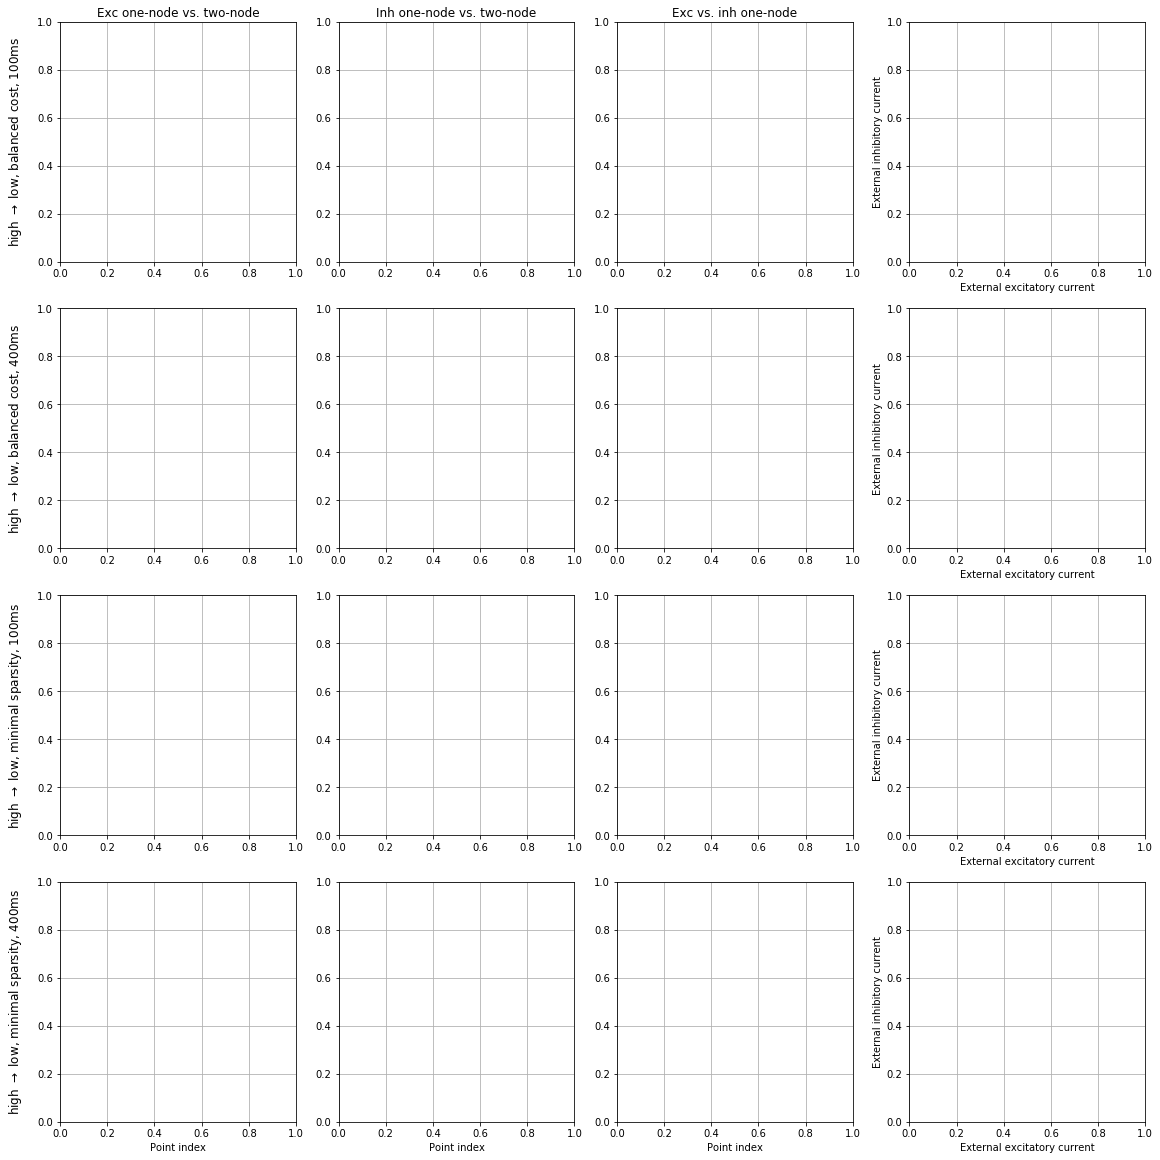

In [75]:
fig7, ax = plt.subplots(4, 4, constrained_layout=True, figsize = (16,16) )

rows = [r'high $\rightarrow$ low, balanced cost, 100ms', r'high $\rightarrow$ low, balanced cost, 400ms',
        r'high $\rightarrow$ low, minimal sparsity, 100ms', r'high $\rightarrow$ low, minimal sparsity, 400ms']

cases = []# [['10000', '10010', '10020'], ['10001', '10011', '10021'],#, '00031', '00041', '00051'],
         #['10100', '10110', '10120'], ['10101', '10111', '10121', '10131', '10141', '10151']]

for k in range(len(cases)):
    print(rows[k])
    readcase(cases[k][0])
    cost_index = np.zeros(( len(ext_exc), 4 ))

    for i in range(len(ext_exc)):
        cost_index[i,0] = i
        for j in range(len(exc_)):
            if exc_[j] == i:
                cost_index[i,1] = cost1[j][0][0][0] + cost1[j][1][0][0] + cost1[j][2][0][0]
        for j in range(len(inh_)):
            if inh_[j] == i:
                cost_index[i,2] = cost2[j][0][0][1] + cost2[j][1][0][1] + cost2[j][2][0][1]
        for j in range(len(both_c_)):
            if both_c_[j] == i:
                cost_index[i,3] = ( cost3[j][0][0][0] + cost3[j][1][0][0] + cost3[j][2][0][0]
                                       + cost3[j][1][0][1] + cost3[j][2][0][1] )
            
    readcase(cases[k][1])

    for i in range(len(ext_exc)):
        for j in range(len(exc_)):
            if exc_[j] == i:
                if cost_index[i,1] == 0.:
                    cost_index[i,1] = cost1[j][0][0][0] + cost1[j][1][0][0] + cost1[j][2][0][0]
                else:
                    print("1 cost index already set, ", cost_index[i,1],
                          cost1[j][0][0][0] + cost1[j][1][0][0] + cost1[j][2][0][0])
        for j in range(len(inh_)):
            if inh_[j] == i:
                if cost_index[i,2] == 0.:
                    cost_index[i,2] = cost2[j][0][0][1] + cost2[j][1][0][1] + cost2[j][2][0][1]
                else:
                    print("2 cost index already set, ", cost_index[i,2],
                          cost2[j][0][0][0] + cost2[j][1][0][1] + cost2[j][2][0][1])
        for j in range(len(both_c_)):
            if both_c_[j] == i:
                if cost_index[i,3] == 0.:
                    cost_index[i,3] = ( cost3[j][0][0][0] + cost3[j][1][0][0] + cost3[j][2][0][0]
                                       + cost3[j][1][0][1] + cost3[j][2][0][1] )
                else:
                    print("3 cost index already set, ", cost_index[i,3], cost3[j][0][0][0] + cost3[j][1][0][0]
                          + cost3[j][2][0][0] + cost3[j][1][0][1] + cost3[j][2][0][1] )

    for i in range(cost_index.shape[0]):
        if cost_index[i,1] != 0 and cost_index[i,3] != 0:
            ax[k,0].plot(i, cost_index[i,1], 'x', color=exc_red)
            ax[k,0].plot(i, cost_index[i,3], 'x', color=green)
            if cost_index[i,1] > cost_index[i,3]:
                print("exc only cost higher than two-node cost: ", i, cost_index[i,1] - cost_index[i,3])
                ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=green)
            else:
                ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=exc_red)
        elif cost_index[i,2] != 0 and cost_index[i,3] != 0:
            ax[k,1].plot(i, cost_index[i,2], 'x', color=inh_blue)
            ax[k,1].plot(i, cost_index[i,3], 'x', color=green)
            if cost_index[i,2] > cost_index[i,3]:
                print("inh only cost higher than two-node cost: ", i, cost_index[i,2] - cost_index[i,3])
                ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=green)
            else:
                ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=inh_blue)
        elif cost_index[i,1] != 0 and cost_index[i,2] != 0:
            ax[k,2].plot(i, cost_index[i,1], 'x', color=exc_red)
            ax[k,2].plot(i, cost_index[i,2], 'x', color=inh_blue)
            if cost_index[i,1] < cost_index[i,2]:
                ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=exc_red)
            elif cost_index[i,1] > cost_index[i,2]:
                ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=inh_blue)
        elif cost_index[i,1] != 0:
            ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=exc_red)
        elif cost_index[i,2] != 0:
            ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=inh_blue)


        dist_x = data.dist_left(ext_exc[i], ext_inh[i], ext_exc, ext_inh, grid_resolution)
        dist_y = data.dist_up(ext_exc[i], ext_inh[i], ext_exc, ext_inh, grid_resolution)

        if (dist_x - dist_y) < - 1e-4 or i > 40:
            ax[k,3].plot(ext_exc[i], ext_inh[i], 'o', alpha=alpha_val, markersize=8, color=exc_red)
        elif (dist_x - dist_y) > 1e-4:
            ax[k,3].plot(ext_exc[i], ext_inh[i], 'o', alpha=alpha_val, markersize=8, color=inh_blue)
        else:
            #print("apparently same distance: ", i, dist_x, dist_y)
            ax[k,3].plot(ext_exc[i], ext_inh[i], 'o', alpha=alpha_val, markersize=8, color='grey')

    ax[k,0].set_ylabel("Total cost")
    ax[k,3].set_xlim(0.3, 0.95)
    ax[k,3].set_ylim(0.3, 0.95)

#######################################################

cols = ['Exc one-node vs. two-node', 'Inh one-node vs. two-node', 'Exc vs. inh one-node']

pad = 5 # in points

for ax_, col in zip(ax[0], cols):
    ax_.annotate(col, xy=(0.5, 1), xytext=(0, pad),
                xycoords='axes fraction', textcoords='offset points',
                size='large', ha='center', va='baseline')

for ax_, row in zip(ax[:,0], rows):
    ax_.annotate(row, xy=(0, 0.5), xytext=(-ax_.yaxis.labelpad - pad, 0),
                xycoords=ax_.yaxis.label, textcoords='offset points',
                size='large', ha='right', va='center', rotation=90)
        

ax[3,0].set_xlabel("Point index")
ax[3,1].set_xlabel("Point index")
ax[3,2].set_xlabel("Point index")

for i in range(4):        
    ax[i,3].set_xlabel("External excitatory current")
    ax[i,3].set_ylabel("External inhibitory current")

plt.savefig(os.path.join(os.getcwd(), 'regions_hl'))

#print(exc_, inh_, both_c_, no_c_)